In [1]:
import os
from pathlib import Path
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf


/home/bonxom/miniconda3/envs/Project2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Text(0, 0.5, 'Amplitude')

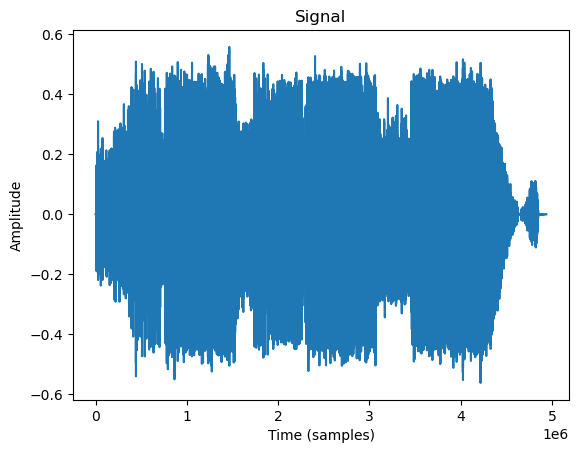

In [ ]:
y, sr = librosa.load('/home/bonxom/Code/AI_Music_detection/archive/fake_songs/fake_00001_suno_0.mp3')
plt.plot(y)
plt.title('Signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')

In [ ]:
audio_path = '/home/bonxom/Code/AI_Music_detection/archive/fake_songs/fake_00001_suno_0.mp3'
clip_seconds = 5

# Giữ nguyên sample rate gốc
y, sr = librosa.load(audio_path, sr=None)
clip_len = int(clip_seconds * sr)

if len(y) <= clip_len:
    start_sample = 0
    clip = y
else:
    start_sample = np.random.randint(0, len(y) - clip_len + 1)
    clip = y[start_sample:start_sample + clip_len]

start_time = start_sample / sr
end_time = start_time + len(clip) / sr

out_path = '/home/bonxom/Code/AI_Music_detection/random_5s_clip.wav'
sf.write(out_path, clip, sr)

print(f'Đã cắt từ {start_time:.2f}s -> {end_time:.2f}s')
print(f'Lưu file: {out_path}')

Đã cắt từ 212.25s -> 217.25s
Lưu file: /home/bonxom/Code/AI_Music_detection/random_5s_clip.wav


“Signal” mô tả tín hiệu âm thanh là sự thay đổi của áp suất không khí theo thời gian; khi số hóa, ta lấy mẫu tín hiệu đó và vẽ thành waveform. Vì vậy trục ngang của biểu đồ là thời gian / số sample, còn trục dọc là amplitude — độ lệch của tín hiệu tại mỗi thời điểm.

/home/bonxom/miniconda3/envs/Project2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Text(0, 0.5, 'Amplitude')

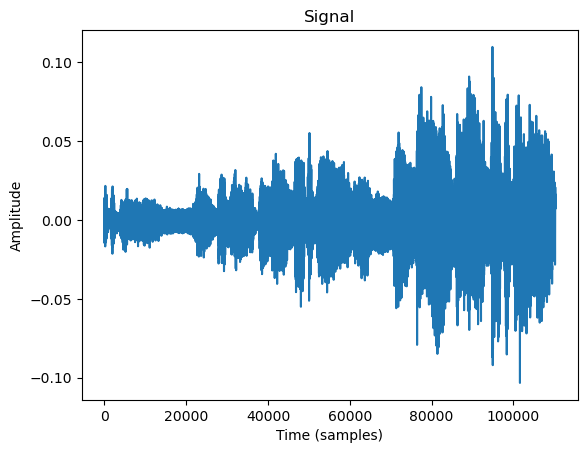

In [ ]:
y, sr = librosa.load('random_5s_clip.wav')
plt.plot(y)
plt.title('Signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')

Fourier Transform là phép biến đổi đưa tín hiệu từ time domain sang frequency domain, tức là từ câu hỏi “tín hiệu thay đổi theo thời gian thế nào” sang “tín hiệu gồm những tần số nào và mỗi tần số mạnh bao nhiêu”. Kết quả của phép biến đổi này được gọi là spectrum.

Một âm thanh thực tế như giọng nói hay nhạc thường là tổ hợp của nhiều sóng tần số khác nhau cộng lại. Trong biểu đồ signal, tất cả các thành phần đó chồng vào nhau nên nhìn rất khó tách. Fourier Transform giúp “bóc” tín hiệu hỗn hợp đó thành các thành phần tần số riêng lẻ, nên spectrum dễ đọc hơn nếu mục tiêu của bạn là phân tích cao độ, hòa âm, formant, hay đặc tính âm sắc

Text(0, 0.5, 'Amplitude')

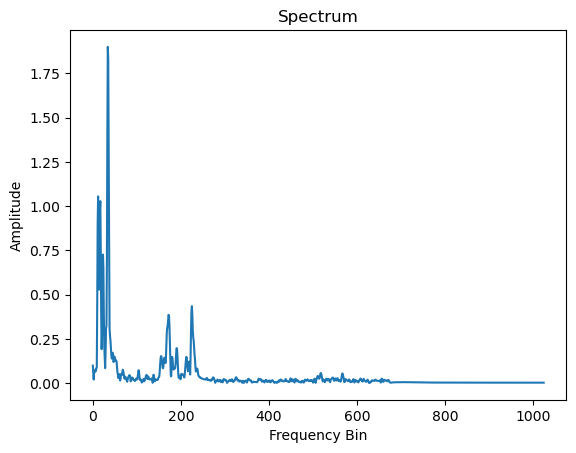

In [ ]:
n_fft = 2048
ft = np.abs(librosa.stft(y[:n_fft], hop_length = n_fft+1))
plt.plot(ft)
plt.title('Spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')

# Crop music file

In [ ]:
audio_path = '/home/bonxom/Code/AI_Music_detection/archive/fake_songs/fake_00001_suno_0.mp3'
clip_seconds = 5

# Giữ nguyên sample rate gốc
y, sr = librosa.load(audio_path, sr=None)
clip_len = int(clip_seconds * sr)

if len(y) <= clip_len:
    start_sample = 0
    clip = y
else:
    start_sample = np.random.randint(0, len(y) - clip_len + 1)
    clip = y[start_sample:start_sample + clip_len]

start_time = start_sample / sr
end_time = start_time + len(clip) / sr

out_path = '/home/bonxom/Code/AI_Music_detection/random_5s_clip.wav'
sf.write(out_path, clip, sr)

print(f'Đã cắt từ {start_time:.2f}s -> {end_time:.2f}s')
print(f'Lưu file: {out_path}')

Đã cắt từ 23.07s -> 28.07s
Lưu file: /home/bonxom/Code/AI_Music_detection/random_5s_clip.wav


In [6]:
def crop_music(type="fake", clip_len=5, start=0, end=None):
    if clip_len not in (5, 120):
        raise ValueError("clip_len must be 5 or 120")
    if type not in("fake",  "real"):
        raise ValueError("clip type invalid")
    in_PATH = "archive/fake_songs"
    out_PATH = "crop_data/crop5/fake"
    if type == "real":
        in_PATH = "archive/real_songs"
        if clip_len==120:
            out_PATH = "crop_data/crop120/real"
        else:
            out_PATH = "crop_data/crop5/real"
    else:
        if clip_len==120:
            out_PATH = "crop_data/crop120/fake"
    

    # Tạo thư mục output nếu chưa tồn tại
    os.makedirs(out_PATH, exist_ok=True)
    
    # Giới hạn độ dài clip (tính bằng sample)
    clip_len_seconds = clip_len
    
    # Duyệt tất cả file trong thư mục input
    audio_files = [f for f in os.listdir(in_PATH)]
    
    # Áp dụng start và end
    audio_files = audio_files[start:end]
    
    print(f"Tìm thấy {len(audio_files)} file âm thanh trong {in_PATH} (từ {start} đến {end})")
    
    for i, filename in enumerate(audio_files, 1):
        try:
            audio_path = os.path.join(in_PATH, filename)
            
            # Load audio file
            y, sr = librosa.load(audio_path, sr=None)
            clip_len_samples = int(clip_len_seconds * sr)
            
            # Xác định vị trí cắt ngẫu nhiên
            if len(y) <= clip_len_samples:
                start_sample = 0
                clip = y
            else:
                start_sample = np.random.randint(0, len(y) - clip_len_samples + 1)
                clip = y[start_sample:start_sample + clip_len_samples]
            
            # Lưu file đã cắt
            # Đổi đuôi file thành .wav
            out_filename = os.path.splitext(filename)[0] + '.wav'
            out_file_path = os.path.join(out_PATH, out_filename)
            
            sf.write(out_file_path, clip, sr)
            
            if i % 100 == 0 or i == len(audio_files):
                print(f"Đã xử lý {i}/{len(audio_files)} file")
        
        except Exception as e:
            print(f"Lỗi xử lý file {filename}: {str(e)}")
    
    print(f"Hoàn thành! Các file đã cắt được lưu trong {out_PATH}")

In [9]:
crop_music("real", 5)

Tìm thấy 4537 file âm thanh trong archive/real_songs (từ 0 đến None)
Đã xử lý 100/4537 file
Đã xử lý 200/4537 file
Đã xử lý 300/4537 file
Đã xử lý 400/4537 file
Đã xử lý 500/4537 file
Đã xử lý 600/4537 file
Đã xử lý 700/4537 file
Đã xử lý 800/4537 file
Đã xử lý 900/4537 file
Đã xử lý 1000/4537 file
Đã xử lý 1100/4537 file
Đã xử lý 1200/4537 file
Đã xử lý 1300/4537 file
Đã xử lý 1400/4537 file
Đã xử lý 1500/4537 file
Đã xử lý 1600/4537 file
Đã xử lý 1700/4537 file
Đã xử lý 1800/4537 file
Đã xử lý 1900/4537 file
Đã xử lý 2000/4537 file
Đã xử lý 2100/4537 file
Đã xử lý 2200/4537 file
Đã xử lý 2300/4537 file
Đã xử lý 2400/4537 file
Đã xử lý 2500/4537 file
Đã xử lý 2600/4537 file
Đã xử lý 2700/4537 file
Đã xử lý 2800/4537 file
Đã xử lý 2900/4537 file
Đã xử lý 3000/4537 file
Đã xử lý 3100/4537 file
Đã xử lý 3200/4537 file
Đã xử lý 3300/4537 file
Đã xử lý 3400/4537 file
Đã xử lý 3500/4537 file
Đã xử lý 3600/4537 file
Đã xử lý 3700/4537 file
Đã xử lý 3800/4537 file
Đã xử lý 3900/4537 file
Đã x